# 06 · Beta: planificado vs real y urgencias estrictas

Este notebook cierra la beta operativa:

- Compara la planificación 18-22 mayo 2026 contra la producción real.
- Convierte la planificación de `CAJ` a `HL` con reglas trazables por SKU.
- Compara secuencias planificadas vs reales por línea.
- Ejecuta el optimizador con órdenes urgentes como restricciones duras.

Si una urgencia no es viable por formato, histórico 2025, línea impuesta o capacidad, el modelo lo reporta como inviabilidad en lugar de inventar una solución.


In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loaders import (
    LINES,
    load_all_operations,
    load_planificado_producciones,
    load_real_production_week,
    planned_demand_from_planificado,
    plan_vs_actual_comparison,
    planned_sequences_from_planificado,
    actual_sequences_from_production,
)
from post_mortem import PostMortemAnalyzer
from scheduling_cp_sat import (
    build_line_behavior_graphs,
    prepare_throughput,
    run_weekly_graph_hours_optimizer,
)

sns.set_theme(style='whitegrid', font_scale=1.0)

DATA_DIR = Path('../raw_data')
START_DATE = '2026-05-18'
END_DATE = '2026-05-22'
HOURS_PER_WEEK = {'14': 110, '17': 115, '19': 115}

print(f'Ventana beta: {START_DATE} -> {END_DATE}')
print('Capacidad usada:', HOURS_PER_WEEK)


Ventana beta: 2026-05-18 -> 2026-05-22
Capacidad usada: {'14': 110, '17': 115, '19': 115}


## 1 · Cargar planificado y producción real

La planificación llega en cajas (`Cntd plan`, unidad `CAJ`). Para compararla con la producción real, se estima:

```text
HL plan = cajas planificadas x unidades por caja x HL por unidad
```

Las unidades por caja se infieren del código SKU (`P24`, `B24`, `L12`, etc.). Si el formato del SKU no se puede inferir, el notebook lo deja marcado para revisión.


In [2]:
df_plan = load_planificado_producciones(
    DATA_DIR / 'Planificado - producciones 14 - 17 - 19.xlsx',
    start_date=START_DATE,
    end_date=END_DATE,
)
df_real = load_real_production_week(
    DATA_DIR / 'Produccion_L14,17,19_18-22.xlsx',
    start_date=START_DATE,
    end_date=END_DATE,
)

comparison = plan_vs_actual_comparison(df_plan, df_real)
plan_sequences = planned_sequences_from_planificado(df_plan)
real_sequences = actual_sequences_from_production(df_real)

print(f'Planificado: {len(df_plan)} filas | {df_plan.sku.nunique()} SKUs | {df_plan.hl_plan.sum():,.1f} HL estimados')
print(f'Real:        {len(df_real)} filas | {df_real.sku.nunique()} SKUs | {df_real.hl_real.sum():,.1f} HL')
print('\nFechas planificadas:', df_plan.fecha_ini.min().date(), '->', df_plan.fecha_ini.max().date())
print('Fechas reales:      ', df_real.fecha_fin.min().date(), '->', df_real.fecha_fin.max().date())


Planificado: 59 filas | 31 SKUs | 43,658.9 HL estimados
Real:        33 filas | 26 SKUs | 38,495.4 HL

Fechas planificadas: 2026-05-18 -> 2026-05-22
Fechas reales:       2026-05-18 -> 2026-05-21


## 2 · Control de conversión y cobertura


In [3]:
unknown_plan = df_plan[df_plan['format'] == 'unknown'].copy()
if unknown_plan.empty:
    print('Todos los SKUs planificados tienen formato inferible.')
else:
    print('SKUs planificados sin formato inferible: revisar antes de usar HL plan como verdad cerrada.')
    print(
        unknown_plan[
            ['start_ts', 'tren', 'sku', 'cntd_plan', 'units_per_case', 'hl_plan']
        ].to_string(index=False)
    )

not_planned = sorted(set(df_real['sku']) - set(df_plan['sku']))
not_produced = sorted(set(df_plan['sku']) - set(df_real['sku']))
print('\nSKUs reales no planificados:', ', '.join(not_planned) if not_planned else 'ninguno')
print('SKUs planificados no producidos:', ', '.join(not_produced) if not_produced else 'ninguno')


SKUs planificados sin formato inferible: revisar antes de usar HL plan como verdad cerrada.
           start_ts tren      sku  cntd_plan  units_per_case  hl_plan
2026-05-22 08:00:00   19 3BNMSL20     134000              20      0.0
2026-05-22 08:00:00   19 3BNZFLB1     345720              24      0.0
2026-05-22 23:59:00   19 3BNZFLB1     516000              24      0.0

SKUs reales no planificados: VI13M12X, VI13P12X
SKUs planificados no producidos: 3BNMSL20, 3BNZFLB1, EN13L24B, ENB13LBF, EX1324NB, SK13LN, VO13LTNN


## 3 · Comparativa por línea y SKU


In [4]:
line_summary = comparison['by_line'].copy()
line_summary['attainment_pct'] = line_summary['attainment_pct'] * 100
print('Resumen por línea')
print(
    line_summary[
        ['tren', 'hl_plan', 'hl_real', 'delta_hl', 'attainment_pct', 'skus_plan', 'skus_real', 'oee_real', 'disp_real', 'rend_real']
    ].to_string(index=False, float_format='{:.2f}'.format)
)

sku_compare = comparison['by_sku'].copy()
sku_compare['attainment_pct'] = sku_compare['attainment_pct'] * 100
print('\nMayores desviaciones por SKU/línea')
print(
    sku_compare.sort_values('abs_delta_hl', ascending=False)[
        ['tren', 'sku', 'status', 'hl_plan', 'hl_real', 'delta_hl', 'attainment_pct', 'oee_real']
    ].head(20).to_string(index=False, float_format='{:.2f}'.format)
)


Resumen por línea
tren  hl_plan  hl_real  delta_hl  attainment_pct  skus_plan  skus_real  oee_real  disp_real  rend_real
  14  8859.55  7420.34  -1439.21           83.76          3          3      0.59       0.74       0.80
  17 18297.42 13605.89  -4691.53           74.36         12         11      0.54       0.58       0.93
  19 16501.92 17469.17    967.25          105.86         16         12      0.64       0.76       0.84

Mayores desviaciones por SKU/línea
tren      sku         status  hl_plan  hl_real  delta_hl  attainment_pct  oee_real
  17   SK13LN   NO_PRODUCIDO  3534.46     0.00  -3534.46            0.00       NaN
  17 VO13LTNN   NO_PRODUCIDO  3296.78     0.00  -3296.78            0.00       NaN
  19 VI13P12X NO_PLANIFICADO     0.00  2616.75   2616.75             NaN      0.81
  17 VI13M12X NO_PLANIFICADO     0.00  2044.80   2044.80             NaN      0.41
  14 ED13LP24      BAJO_PLAN  6961.68  5121.24  -1840.44           73.56      0.65
  19 EX1324NB   NO_PRODUCIDO  1188.0

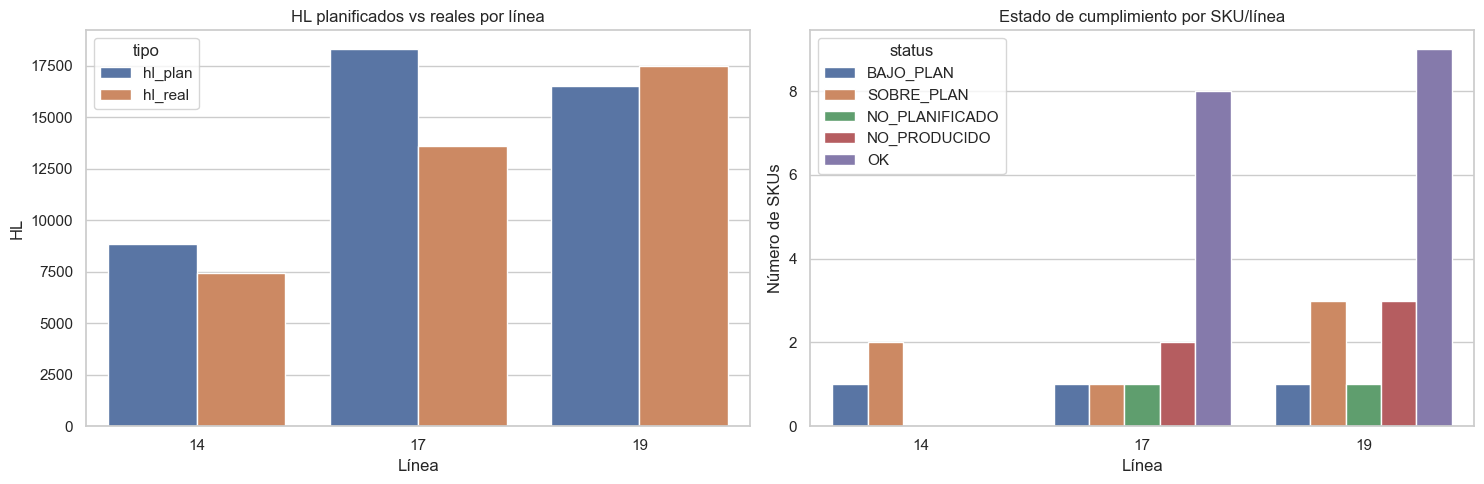

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_line = line_summary.melt(
    id_vars='tren',
    value_vars=['hl_plan', 'hl_real'],
    var_name='tipo',
    value_name='hl',
)
sns.barplot(data=plot_line, x='tren', y='hl', hue='tipo', ax=axes[0])
axes[0].set_title('HL planificados vs reales por línea')
axes[0].set_xlabel('Línea')
axes[0].set_ylabel('HL')

status_counts = sku_compare.groupby(['tren', 'status']).size().reset_index(name='n')
sns.barplot(data=status_counts, x='tren', y='n', hue='status', ax=axes[1])
axes[1].set_title('Estado de cumplimiento por SKU/línea')
axes[1].set_xlabel('Línea')
axes[1].set_ylabel('Número de SKUs')

plt.tight_layout()
plt.show()


## 4 · Secuencia planificada vs real


In [6]:
sequence_rows = []
for line in LINES:
    planned = plan_sequences.get(line, [])
    actual = real_sequences.get(line, [])
    all_skus = list(dict.fromkeys(planned + actual))
    for sku in all_skus:
        planned_pos = planned.index(sku) + 1 if sku in planned else np.nan
        actual_pos = actual.index(sku) + 1 if sku in actual else np.nan
        if pd.isna(planned_pos):
            status = 'NO_PLANIFICADO'
        elif pd.isna(actual_pos):
            status = 'NO_PRODUCIDO'
        elif planned_pos == actual_pos:
            status = 'MISMA_POSICION'
        else:
            status = 'CAMBIO_POSICION'
        sequence_rows.append(
            {
                'linea': line,
                'sku': sku,
                'pos_plan': planned_pos,
                'pos_real': actual_pos,
                'delta_pos': actual_pos - planned_pos if pd.notna(planned_pos) and pd.notna(actual_pos) else np.nan,
                'status': status,
            }
        )

sequence_compare = pd.DataFrame(sequence_rows)
for line in LINES:
    print(f'\nLínea {line}')
    print(sequence_compare[sequence_compare.linea == line].to_string(index=False))



Línea 14
linea      sku  pos_plan  pos_real  delta_pos          status
   14  FDT13LT       1.0       2.0        1.0 CAMBIO_POSICION
   14 ED13LP24       2.0       1.0       -1.0 CAMBIO_POSICION
   14 VO13LP24       3.0       3.0        0.0  MISMA_POSICION

Línea 17
linea      sku  pos_plan  pos_real  delta_pos          status
   17 XI13P24M       1.0       1.0        0.0  MISMA_POSICION
   17  XI13LTN       2.0       3.0        1.0 CAMBIO_POSICION
   17 FD13LTNN       3.0       2.0       -1.0 CAMBIO_POSICION
   17  FDL13LN       4.0       5.0        1.0 CAMBIO_POSICION
   17   DL13LT       5.0       6.0        1.0 CAMBIO_POSICION
   17 KE13PL12       6.0      10.0        4.0 CAMBIO_POSICION
   17 KE13LTNN       7.0       8.0        1.0 CAMBIO_POSICION
   17  TU13LTN       8.0       7.0       -1.0 CAMBIO_POSICION
   17  TUP13LT       9.0       9.0        0.0  MISMA_POSICION
   17 LC13LTNN      10.0      11.0        1.0 CAMBIO_POSICION
   17   SK13LN      11.0       NaN        NaN    N

## 5 · Preparar grafo histórico 2025


In [7]:
dfs = load_all_operations(DATA_DIR)
analyzer = PostMortemAnalyzer(
    df_oee=dfs['oee'],
    df_cambios=dfs['cam'],
    df_mantenimiento=dfs['mant'],
    df_tiempo=dfs['tiem'],
    df_volumen=dfs['vol'],
)
analyzer.clean_and_isolate_maintenance()

# Obtener matrices de transición usando el modelo de grafos suavizado
all_skus_week = list(set(df_plan['sku'].dropna().unique()).union(set(df_real['sku'].dropna().unique())))
matrices = analyzer.build_transition_matrices()
graphs = build_line_behavior_graphs(matrices)
throughput = prepare_throughput(dfs)

print('Grafo 2025 por línea')
for line, graph in graphs.items():
    print(f'L{line}: {graph.number_of_nodes()} nodos | {graph.number_of_edges()} aristas')


[clean_and_isolate_maintenance] OFs contaminadas (>20%): 293/2141 (13.7%)
  → imputadas por mediana SKU-línea (>50%): 105
[build_transition_matrices] Línea 14: 236 transiciones únicas (59 nodos origen, 60 nodos destino)
[build_transition_matrices] Línea 17: 567 transiciones únicas (94 nodos origen, 93 nodos destino)
[build_transition_matrices] Línea 19: 555 transiciones únicas (115 nodos origen, 113 nodos destino)
Grafo 2025 por línea
L14: 63 nodos | 236 aristas
L17: 94 nodos | 567 aristas
L19: 117 nodos | 555 aristas


## 6 · Diagnóstico del plan 18-22 con el modelo beta

Este paso intenta optimizar la demanda planificada. Si no cabe, el resultado también es información: indica que con las restricciones actuales de formato, histórico 2025 y capacidad, esa planificación necesita revisión o reglas adicionales.


In [8]:
plan_demand = planned_demand_from_planificado(df_plan)
plan_results = run_weekly_graph_hours_optimizer(
    demanda_semanal=plan_demand,
    dfs=dfs,
    matrices=matrices,
    throughput=throughput,
    hours_per_week=HOURS_PER_WEEK,
    original_sequences=plan_sequences,
    time_limit=30.0,
    drop_ineligible=True,
    fixed_original_lines=True,
)

print('Estado optimización sobre planificado:', plan_results.get('_status'))
if plan_results.get('_ineligible_skus'):
    print('SKUs fuera del modelo por falta de evidencia/formato:', ', '.join(plan_results['_ineligible_skus']))
if not plan_results.get('_fixed_line_conflicts', pd.DataFrame()).empty:
    print('SKUs descartados por no poder quedarse en su línea original con evidencia 2025:')
    print(plan_results['_fixed_line_conflicts'].to_string(index=False))

if plan_results.get('_status') in ('OPTIMAL', 'FEASIBLE'):
    rows = []
    for line in LINES:
        r = plan_results[line]
        rows.append({
            'linea': line,
            'horas_optimizadas': r['hours_optimized'],
            'horas_sobrantes': r['spare_hours'],
            'capacity_ok': r['capacity_ok'],
            'secuencia': ' -> '.join(r['seq_optimized']),
        })
    print(pd.DataFrame(rows).to_string(index=False, float_format='{:.2f}'.format))
else:
    print('El plan completo cubierto por histórico no es factible con la beta actual. Se conserva el diagnóstico y se prueba la lógica de urgencias sobre una demanda viable.')


Estado optimización sobre planificado: FEASIBLE
linea  horas_optimizadas  horas_sobrantes  capacity_ok                                                                                                                                                                          secuencia
   14              74.38            35.62         True                                                                                                                                                    FDT13LT -> ED13LP24 -> VO13LP24
   17             118.01            -3.01        False                                               XI13P24M -> XI13LTN -> FD13LTNN -> FDL13LN -> DL13LT -> KE13PL12 -> KE13LTNN -> TU13LTN -> TUP13LT -> LC13LTNN -> SK13LN -> VO13LTNN
   19             120.86            -5.86        False XI13L12M -> EX12LB24 -> EN12B24I -> EX12LBN -> VO12LT -> ED12LTW -> DL12LT -> LC12LTW -> VI12LTW -> VI12LTX -> ID12LBN -> EN13L24B -> EX1324NB -> ENB13LBF -> 3BNMSL20 -> 3BNZFLB1


## 7 · Órdenes urgentes como restricciones duras

Edita `URGENT_ORDERS` para probar casos reales.

Campos soportados:

- `sku`: SKU obligatorio.
- `linea`: línea impuesta opcional (`14`, `17`, `19`).
- `hl_total`: volumen adicional en HL si el SKU no estaba en la demanda o si se quiere sumar volumen.
- `latest_position`: posición máxima permitida dentro de la secuencia de su línea.


In [9]:
URGENT_ORDERS = [
    {
        'order_id': 'URG-ADD-ED13LTW',
        'sku': 'ED13LTW',
        'linea': '19',
        'hl_total': 200.0,
        'latest_position': 3,
    }
]

print(pd.DataFrame(URGENT_ORDERS).to_string(index=False))


       order_id     sku linea  hl_total  latest_position
URG-ADD-ED13LTW ED13LTW    19     200.0                3


In [10]:
actual_demand = (
    df_real.groupby(['tren', 'sku'], as_index=False)['hl_real']
    .sum()
    .rename(columns={'hl_real': 'hl_total'})
)
actual_demand['original_tren'] = actual_demand['tren']

base_results = run_weekly_graph_hours_optimizer(
    demanda_semanal=actual_demand,
    dfs=dfs,
    matrices=matrices,
    throughput=throughput,
    hours_per_week=HOURS_PER_WEEK,
    original_sequences=real_sequences,
    time_limit=30.0,
    drop_ineligible=True,
    fixed_original_lines=True,
)

urgent_results = run_weekly_graph_hours_optimizer(
    demanda_semanal=actual_demand,
    dfs=dfs,
    matrices=matrices,
    throughput=throughput,
    hours_per_week=HOURS_PER_WEEK,
    original_sequences=real_sequences,
    time_limit=30.0,
    drop_ineligible=True,
    fixed_original_lines=True,
    urgent_orders=URGENT_ORDERS,
)

print('Estado base:', base_results.get('_status'))
print('Estado con urgencia:', urgent_results.get('_status'))
for label, results in [('base', base_results), ('urgencia', urgent_results)]:
    if results.get('_ineligible_skus'):
        print(f'SKUs excluidos en {label} por falta de evidencia/formato:', ', '.join(results['_ineligible_skus']))
    if not results.get('_fixed_line_conflicts', pd.DataFrame()).empty:
        print(f'Conflictos línea fija en {label}:')
        print(results['_fixed_line_conflicts'].to_string(index=False))
if not urgent_results.get('_urgent_errors', pd.DataFrame()).empty:
    print(urgent_results['_urgent_errors'].to_string(index=False))


Estado base: FEASIBLE
Estado con urgencia: FEASIBLE


In [11]:
def summarize_solution(results, label):
    if results.get('_status') not in ('OPTIMAL', 'FEASIBLE'):
        return pd.DataFrame([{'escenario': label, 'status': results.get('_status')}])
    rows = []
    for line in LINES:
        r = results[line]
        rows.append(
            {
                'escenario': label,
                'linea': line,
                'horas_optimizadas': r['hours_optimized'],
                'horas_sobrantes': r['spare_hours'],
                'prod_h': r['prod_hours'],
                'transicion_h': r['transition_hours'],
                'capacity_ok': r['capacity_ok'],
                'secuencia': ' -> '.join(r['seq_optimized']),
            }
        )
    return pd.DataFrame(rows)

solution_summary = pd.concat(
    [
        summarize_solution(base_results, 'base_real'),
        summarize_solution(urgent_results, 'con_urgencia'),
    ],
    ignore_index=True,
)
print(solution_summary.to_string(index=False, float_format='{:.2f}'.format))

for order in URGENT_ORDERS:
    sku = order['sku']
    print(f"\nValidación urgencia {order['order_id']} | SKU {sku}")
    for label, results in [('base', base_results), ('urgencia', urgent_results)]:
        if results.get('_status') not in ('OPTIMAL', 'FEASIBLE'):
            print(label, 'sin solución')
            continue
        found = False
        for line in LINES:
            seq = results[line]['seq_optimized']
            if sku in seq:
                print(f"{label}: L{line}, posición {seq.index(sku) + 1}, horas línea {results[line]['hours_optimized']:.2f}")
                found = True
        if not found:
            print(label, 'SKU no programado')


   escenario linea  horas_optimizadas  horas_sobrantes  prod_h  transicion_h  capacity_ok                                                                                                                          secuencia
   base_real    14              63.51            46.49   61.51          2.00         True                                                                                                    ED13LP24 -> FDT13LT -> VO13LP24
   base_real    17              95.62            19.38   85.62         10.00         True         DL13LT -> FD13LTNN -> FDL13LN -> KE13LTNN -> KE13PL12 -> LC13LTNN -> TU13LTN -> TUP13LT -> VI13M12X -> XI13LTN -> XI13P24M
   base_real    19             117.67            -2.67  106.67         11.00        False DL12LT -> ED12LTW -> EN12B24I -> EX12LB24 -> EX12LBN -> ID12LBN -> LC12LTW -> VI12LTW -> VI12LTX -> VI13P12X -> VO12LT -> XI13L12M
con_urgencia    14              63.51            46.49   61.51          2.00         True                           

## 8 · Gantt de la solución con urgencia


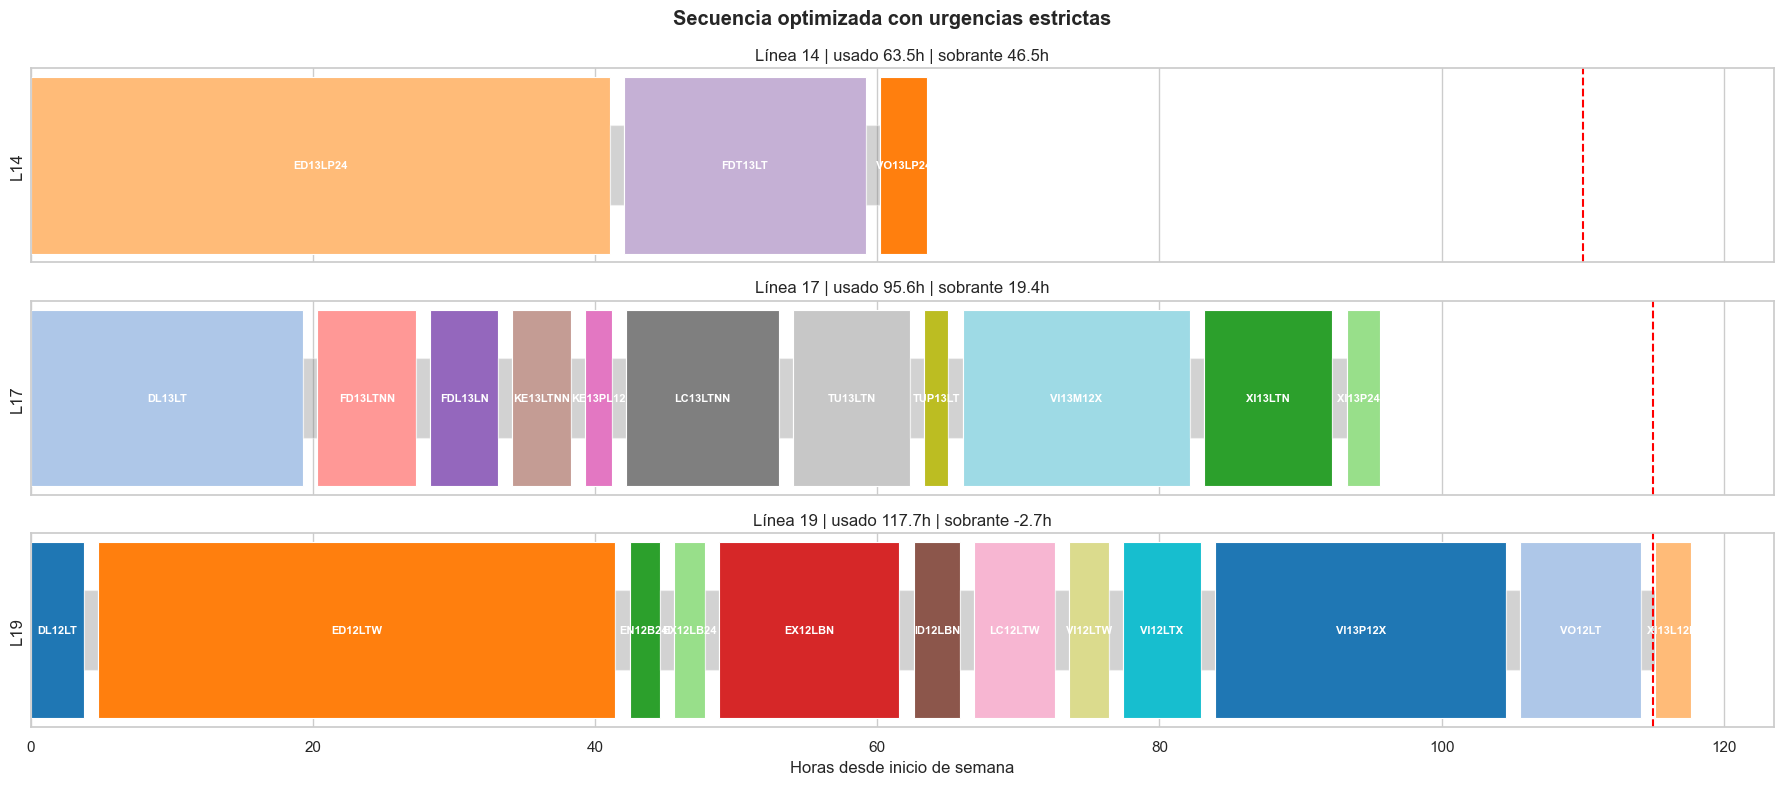

In [12]:
schedule_df = urgent_results.get('_schedule_df', pd.DataFrame()).copy()
if schedule_df.empty:
    print('No hay solución con urgencia para visualizar.')
else:
    palette = dict(zip(sorted(schedule_df['sku'].unique()), sns.color_palette('tab20', n_colors=schedule_df['sku'].nunique())))
    fig, axes = plt.subplots(len(LINES), 1, figsize=(18, 8), sharex=True)
    if len(LINES) == 1:
        axes = [axes]

    urgent_skus = {order['sku'] for order in URGENT_ORDERS}
    for ax, line in zip(axes, LINES):
        det = schedule_df[schedule_df['line'] == line].sort_values('sequence_order')
        for _, item in det.iterrows():
            transition_h = float(item['transition_h'])
            prod_h = float(item['prod_h'])
            setup_start = max(float(item['start_h']) - transition_h, 0)
            if transition_h > 0:
                ax.barh(0, transition_h, left=setup_start, height=0.25, color='gray', alpha=0.35)
            edge_color = 'black' if item['sku'] in urgent_skus else 'white'
            edge_width = 2.0 if item['sku'] in urgent_skus else 0.8
            ax.barh(
                0,
                prod_h,
                left=float(item['start_h']),
                height=0.55,
                color=palette[item['sku']],
                edgecolor=edge_color,
                linewidth=edge_width,
            )
            if prod_h > 1.2:
                ax.text(
                    float(item['start_h']) + prod_h / 2,
                    0,
                    str(item['sku'])[:9],
                    ha='center',
                    va='center',
                    fontsize=8,
                    color='white',
                    fontweight='bold',
                )
        ax.axvline(HOURS_PER_WEEK[line], color='red', linestyle='--', lw=1.5)
        ax.set_title(
            f"Línea {line} | usado {urgent_results[line]['hours_optimized']:.1f}h | sobrante {urgent_results[line]['spare_hours']:.1f}h"
        )
        ax.set_yticks([])
        ax.set_ylabel(f'L{line}')

    axes[-1].set_xlabel('Horas desde inicio de semana')
    plt.suptitle('Secuencia optimizada con urgencias estrictas', fontweight='bold')
    plt.tight_layout()
    plt.show()
